# Лабораторная 7

## Задание
### Датасет: Celeba https://www.kaggle.com/datasets/jessicali9530/celeba-dataset

In [1]:
import numpy as np
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import os
from torchvision.utils import make_grid, save_image
from tqdm import tqdm
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
import torch.nn as nn
import torch.autograd as autograd
import torch.optim as optim
from config import *
import matplotlib.pyplot as plt
import torch
import torchvision.utils as vutils

#### Подготовить датасет: использовать детектор/сегментатор для предварительного вырезания лиц людей. Можно также добавить технику выравнивания лица (не обязательно)

##### Выполнил в отдельном скрипте Prepare.py, чтобы не приходилось заново перезапускать при каждом перезапуске обучения

#### Обучить !самописный! GAN для задачи безусловной генерации лиц
##### Метрики: посчитать FID и IS, показать кривые обучения

In [2]:
class MyDataset1(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir= root_dir
        self.transform= transform
        self.image_files =sorted([f for f in os.listdir(root_dir) if f.endswith('.jpg')])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_name).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5, 0.5))
])

dataset= MyDataset1(root_dir=data_dir, transform=transform)
dataloader=DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

print(f"Всего {len(dataset)} ")

Всего 49913 


In [3]:
class Generator1(nn.Module):
    def __init__(self):
        super(Generator1, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_size, img_size * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(img_size * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(img_size * 8, img_size * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(img_size * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(img_size * 4, img_size * 2,4,2,1, bias=False),
            nn.BatchNorm2d(img_size * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(img_size * 2, img_size, 4, 2, 1, bias=False),
            nn.BatchNorm2d(img_size),
            nn.ReLU(True),
            nn.ConvTranspose2d(img_size, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, x): return self.main(x)

class Discriminator1(nn.Module):
    def __init__(self):
        super(Discriminator1, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, img_size, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(img_size, img_size * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(img_size * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(img_size * 2, img_size * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(img_size * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(img_size * 4, img_size * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(img_size * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(img_size * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x): return self.main(x).view(-1)

In [4]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [5]:
device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
g1 =Generator1().to(device)
d1 =Discriminator1().to(device)
g1.apply(weights_init)
d1.apply(weights_init)

criterion = nn.BCELoss()
optimizerD = optim.Adam(d1.parameters(), lr=lr_D, betas=(0.5, 0.999))
optimizerG = optim.Adam(g1.parameters(), lr=lr_G, betas=(0.5, 0.999))

fixed_noise = torch.randn(64, latent_size, 1, 1, device=device)
fixed_batch= next(iter(dataloader))[:64].to(device)

In [7]:
os.makedirs("imgs1", exist_ok=True)
os.makedirs("weights", exist_ok=True)

history = {'d_loss': [], 'g_loss': [], 'D_x': [], 'D_G_z': [],'fid': [], 'is_mean': []
}

fid = FrechetInceptionDistance(feature=2048).to(device)
IS = InceptionScore().to(device)

for epoch in range(epochs):
    g1.train()
    d1.train()

    epoch_d_loss= 0
    epoch_g_loss= 0
    epoch_dx= 0
    epoch_dgz = 0
    train_bar= tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

    for imgs in train_bar:
        imgs = imgs.to(device)
        b_size = imgs.size(0)

        optimizerD.zero_grad()
        real_l= torch.full((b_size,), 0.9, device=device)
        fake_l= torch.zeros(b_size, device=device)

        output_real = d1(imgs)
        lossD_real = criterion(output_real, real_l)
        D_x = output_real.mean().item()

        noise = torch.randn(b_size, lat_dim, 1, 1, device=device)
        fake_imgs = g1(noise)
        output_fake = d1(fake_imgs.detach())
        lossD_fake = criterion(output_fake, fake_l)

        lossD = lossD_real+lossD_fake
        lossD.backward()
        torch.nn.utils.clip_grad_norm_(d1.parameters(), max_norm=1.0)
        optimizerD.step()

        tar = torch.ones(b_size, device=device)

        optimizerG.zero_grad()
        output_fake_G = d1(fake_imgs)
        lossG1 = criterion(output_fake_G, tar)
        lossG1.backward()
        optimizerG.step()

        noise2 = torch.randn(b_size, lat_dim, 1, 1, device=device)
        fake_imgs_2 = g1(noise2)
        optimizerG.zero_grad()
        output_fake_G_2 = d1(fake_imgs_2)
        lossG2 = criterion(output_fake_G_2, tar)
        lossG2.backward()
        torch.nn.utils.clip_grad_norm_(g1.parameters(), max_norm=1.0)
        optimizerG.step()

        D_G_z2 = output_fake_G_2.mean().item()
        epoch_d_loss+=lossD.item()
        epoch_g_loss+= lossG2.item()
        epoch_dx+= D_x
        epoch_dgz+=D_G_z2
        train_bar.set_postfix(L_D=f"{lossD.item():.3f}", L_G=f"{lossG2.item():.3f}")
    train_bar.close()

    avg_d_loss= epoch_d_loss/len(dataloader)
    avg_g_loss =epoch_g_loss / len(dataloader)
    avg_dx= epoch_dx / len(dataloader)
    avg_dgz= epoch_dgz/ len(dataloader)

    history['d_loss'].append(avg_d_loss)
    history['g_loss'].append(avg_g_loss)
    history['D_x'].append(avg_dx)
    history['D_G_z'].append(avg_dgz)

    is_eval_epoch= (epoch + 1) % 5 == 0 or epoch== epochs - 1
    if is_eval_epoch:
        g1.eval()
        fid.reset()
        IS.reset()

        print(f"\n[Epoch {epoch+1}]")
        with torch.no_grad():
            fake_display = g1(fixed_noise)
            gen_pic = make_grid(fake_display, nrow=8, padding=2, normalize=True)
            save_image(gen_pic, f"imgs1/epoch_{epoch+1}.png")

            s= 1000
            b=50
            real_iter = iter(dataloader)
            for _ in range(s // b):
                try:
                    real_imgs = next(real_iter).to(device)
                except StopIteration:
                    real_iter = iter(dataloader)
                    real_imgs = next(real_iter).to(device)

                z = torch.randn(b, lat_dim, 1, 1, device=device)
                fakes = g1(z)
                fid.update(((real_imgs*0.5+0.5)* 255).clamp(0, 255).to(torch.uint8), real=True)
                fid.update(((fakes* 0.5+ 0.5) * 255).clamp(0, 255).to(torch.uint8), real=False)
                IS.update(((fakes* 0.5 +0.5) *255).clamp(0, 255).to(torch.uint8))

        cur_fid = fid.compute().item()
        cur_is, _ = IS.compute()

        history['fid'].append(cur_fid)
        history['is_mean'].append(cur_is.item())
        print(f"Epoch {epoch+1} | D Loss: {avg_d_loss:.2f} | G Loss: {avg_g_loss:.2f} | FID: {cur_fid:.2f} | IS: {cur_is.item():.2f}")

        torch.save(g1.state_dict(), f'weights/netG_epoch_{epoch+1}.pth')

C:\Users\gerta\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)



[Epoch 5]
Epoch 5 | D Loss: 1.44 | G Loss: 0.90 | FID: 223.11 | IS: 2.69



[Epoch 10]
Epoch 10 | D Loss: 1.43 | G Loss: 0.82 | FID: 126.85 | IS: 2.27



[Epoch 15]
Epoch 15 | D Loss: 1.40 | G Loss: 0.80 | FID: 85.55 | IS: 1.94



[Epoch 20]
Epoch 20 | D Loss: 1.44 | G Loss: 0.83 | FID: 104.73 | IS: 2.09


...


[Epoch 30]
Epoch 30 | D Loss: 1.31 | G Loss: 0.95 | FID: 66.34 | IS: 2.09



[Epoch 35]
Epoch 35 | D Loss: 1.00 | G Loss: 0.78 | FID: 68.40 | IS: 2.08



[Epoch 40]
Epoch 40 | D Loss: 1.13 | G Loss: 1.66 | FID: 57.26 | IS: 2.01



[Epoch 45]
Epoch 45 | D Loss: 0.75 | G Loss: 1.38 | FID: 52.69 | IS: 1.91



[Epoch 50]
Epoch 50 | D Loss: 0.69 | G Loss: 1.54 | FID: 50.24 | IS: 2.09


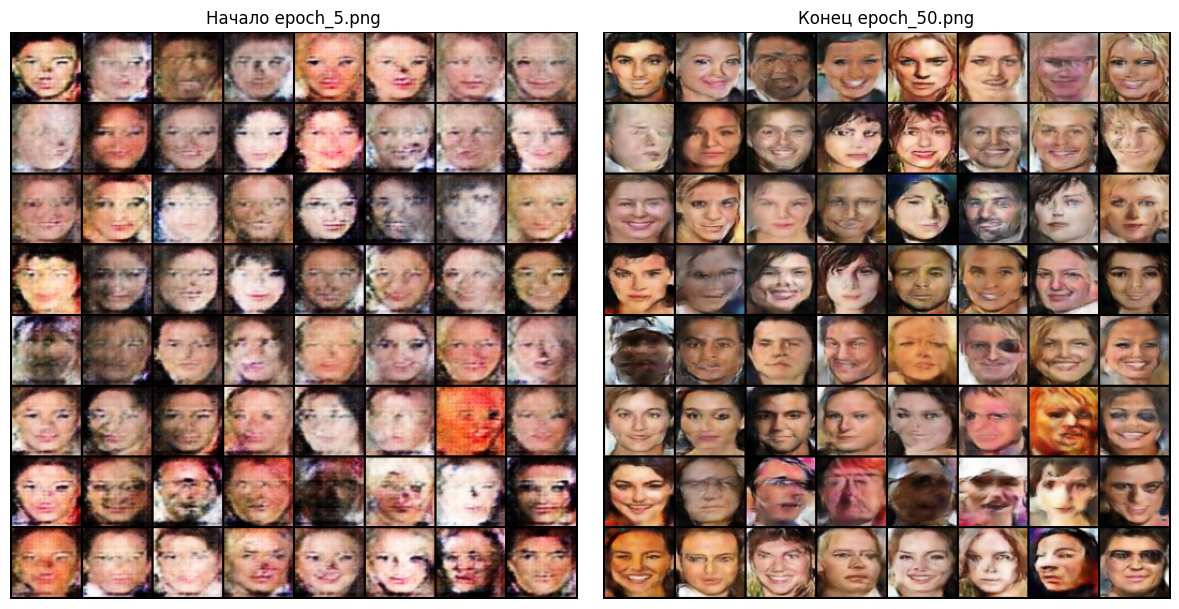

In [25]:
%matplotlib inline

files= [os.path.join("imgs1", f) for f in os.listdir("imgs1") if f.endswith('.png')]
if not files:
    print("пусто")
else:
    files.sort(key=os.path.getmtime)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(plt.imread(files[0]))
    plt.title(f"Начало {os.path.basename(files[0])}")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(plt.imread(files[-1]))
    plt.title(f"Конец {os.path.basename(files[-1])}")
    plt.axis('off')
    plt.tight_layout()
    plt.show();

#### А затем эту же сетку преобразовать в условную и обучить для задачи условной генерации лиц по полу человека (или любому другому признаку)
##### Генерация по половому признаку

In [9]:
class MyDataset2(Dataset):
    def __init__(self, img_dir, attr_file, transform=None):
        self.img_dir = img_dir
        self.transform = transform

        df = pd.read_csv(attr_file)
        df['Male'] = df['Male'].replace(-1, 0)
        existing_files = set(os.listdir(img_dir))
        df = df[df['image_id'].isin(existing_files)]

        self.image_files = df['image_id'].tolist()
        self.labels = df['Male'].tolist()

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.image_files[idx])
        image = Image.open(img_name).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

attr_path = 'archive/list_attr_celeba.csv'

cond_dataset = MyDataset2(img_dir=data_dir, attr_file=attr_path, transform=transform)
cond_dataloader = DataLoader(cond_dataset, batch_size=128, shuffle=True, num_workers=0)
print(f"Всего {len(cond_dataset)} ")

Всего 49913 


In [11]:
class Generator2(nn.Module):
    def __init__(self):
        super(Generator2, self).__init__()
        self.label_emb = nn.Embedding(2, embed_dim)

        input_dim = lat_dim+ embed_dim
        self.main = nn.Sequential(
            nn.ConvTranspose2d(input_dim, img_size * 8,4,1, 0, bias=False),
            nn.BatchNorm2d(img_size * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(img_size* 8, img_size * 4,4, 2, 1, bias=False),
            nn.BatchNorm2d(img_size * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(img_size * 4, img_size * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(img_size * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(img_size * 2, img_size, 4, 2, 1, bias=False),
            nn.BatchNorm2d(img_size),
            nn.ReLU(True),
            nn.ConvTranspose2d(img_size, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self,noise, labels):
        c=self.label_emb(labels).unsqueeze(2).unsqueeze(3)
        x= torch.cat([noise, c], dim=1)
        return self.main(x)

class Discriminator2(nn.Module):
    def __init__(self):
        super(Discriminator2, self).__init__()
        self.label_emb = nn.Embedding(2, embed_dim)
        self.label_linear = nn.Linear(embed_dim, 64 * 64)

        self.main = nn.Sequential(
            nn.Conv2d(nc + 1, img_size, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(img_size, img_size * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(img_size * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(img_size * 2, img_size * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(img_size * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(img_size * 4, img_size * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(img_size * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(img_size * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        c = self.label_emb(labels)
        c = self.label_linear(c).view(-1, 1, 64, 64)
        x = torch.cat([img, c], dim=1)
        return self.main(x).view(-1)

In [12]:
g2= Generator2().to(device)
d2= Discriminator2().to(device)
g2.apply(weights_init)
d2.apply(weights_init)

criterion = nn.BCELoss()
optimizerD = optim.Adam(d2.parameters(),lr=lr_D, betas=(0.5, 0.999))
optimizerG = optim.Adam(g2.parameters(),lr=lr_G, betas=(0.5, 0.999))

test_noise= torch.randn(32, lat_dim,1,1, device=device)
test_labels_f =torch.zeros(32, dtype=torch.long, device=device)
test_labels_m=torch.ones(32, dtype=torch.long, device=device)


In [13]:
history_cond = {'d_loss': [], 'g_loss': [],'D_x': [], 'D_G_z': [],'fid': [], 'is_mean': []}

os.makedirs("imgs2", exist_ok=True)
os.makedirs("weights_cond", exist_ok=True)

for epoch in range(epochs):
    g2.train()
    d2.train()

    epoch_d_loss, epoch_g_loss = 0, 0
    epoch_dx, epoch_dgz = 0, 0

    train_bar = tqdm(cond_dataloader, desc=f"CGAN Epoch {epoch+1}/{epochs}", leave=False)

    for imgs, labels in train_bar:
        b_size = imgs.size(0)
        imgs, labels = imgs.to(device), labels.to(device)

        optimizerD.zero_grad()

        real_l = torch.full((b_size,), 0.9, device=device)
        fake_l = torch.zeros(b_size, device=device)

        output_real = d2(imgs, labels)
        errD_real = criterion(output_real, real_l)
        D_x = output_real.mean().item() 

        noise= torch.randn(b_size, lat_dim, 1, 1, device=device)
        fake_imgs= g2(noise, labels)
        output_fake= d2(fake_imgs.detach(), labels)
        errD_fake =criterion(output_fake, fake_l)

        lossD = errD_real + errD_fake
        lossD.backward()
        torch.nn.utils.clip_grad_norm_(d2.parameters(), max_norm=1.0)
        optimizerD.step()

        optimizerG.zero_grad()
        tar = torch.ones(b_size, device=device)

        output_fake_G = d2(fake_imgs, labels)
        lossG1 = criterion(output_fake_G, tar)
        lossG1.backward()
        optimizerG.step()

        noise2 = torch.randn(b_size, lat_dim, 1, 1, device=device)
        fake_imgs_2 = g2(noise2, labels)

        optimizerG.zero_grad()
        output_fake_G_2 = d2(fake_imgs_2, labels)
        lossG2 = criterion(output_fake_G_2, tar)
        lossG2.backward()
        torch.nn.utils.clip_grad_norm_(g2.parameters(), max_norm=1.0)
        optimizerG.step()

        D_G_z2 = output_fake_G_2.mean().item()
        epoch_d_loss+= lossD.item()
        epoch_g_loss+= lossG2.item()
        epoch_dx+= D_x
        epoch_dgz+= D_G_z2

        train_bar.set_postfix(L_D=f"{lossD.item():.3f}", L_G=f"{lossG2.item():.3f}")
    train_bar.close()

    avg_d_loss = epoch_d_loss / len(cond_dataloader)
    avg_g_loss = epoch_g_loss / len(cond_dataloader)
    avg_dx = epoch_dx / len(cond_dataloader)
    avg_dgz = epoch_dgz / len(cond_dataloader)

    history_cond['d_loss'].append(avg_d_loss)
    history_cond['g_loss'].append(avg_g_loss)
    history_cond['D_x'].append(avg_dx)
    history_cond['D_G_z'].append(avg_dgz)

    is_eval_epoch = (epoch + 1) % 5 == 0 or epoch == epochs - 1

    if is_eval_epoch:
        g2.eval()
        fid.reset()
        IS.reset()

        print(f"\n[Epoch {epoch+1}]")
        with torch.no_grad():
            fakes_f = g2(test_noise, test_labels_f)
            fakes_m = g2(test_noise, test_labels_m)
            combined = torch.cat([fakes_f, fakes_m], dim=0)
            grid = make_grid(combined, nrow=8, normalize=True)
            save_image(grid, f"imgs2/epoch_{epoch+1}.png")

            s=1000
            b=50
            real_iter = iter(cond_dataloader)

            for _ in range(s// b):
                try:
                    real_imgs, _ = next(real_iter)
                except StopIteration:
                    real_iter = iter(cond_dataloader)
                    real_imgs, _ = next(real_iter)

                real_imgs = real_imgs.to(device)

                z = torch.randn(b, lat_dim, 1, 1, device=device)
                eval_labels = torch.randint(0, 2, (b,), device=device)
                fakes = g2(z, eval_labels)

                fid.update(((real_imgs *0.5 +0.5) * 255).clamp(0,255).to(torch.uint8), real=True)
                fid.update(((fakes * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8), real=False)
                IS.update(((fakes * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8))

        cur_fid = fid.compute().item()
        cur_is, _ = IS.compute()

        history_cond['fid'].append(cur_fid)
        history_cond['is_mean'].append(cur_is.item())

        print(f"Epoch {epoch+1} | D Loss: {avg_d_loss:.2f} | G Loss: {avg_g_loss:.2f} | FID: {cur_fid:.2f} | IS: {cur_is.item():.2f}")

        torch.save(g2.state_dict(), f'weights_cond/netG_epoch_{epoch+1}.pth')


[Epoch 5]
Epoch 5 | D Loss: 1.49 | G Loss: 0.90 | FID: 304.49 | IS: 2.37



[Epoch 10]
Epoch 10 | D Loss: 1.41 | G Loss: 0.86 | FID: 259.31 | IS: 2.25



[Epoch 15]
Epoch 15 | D Loss: 1.36 | G Loss: 0.86 | FID: 260.30 | IS: 2.49



[Epoch 20]
Epoch 20 | D Loss: 1.30 | G Loss: 0.85 | FID: 159.92 | IS: 1.60



[Epoch 25]
Epoch 25 | D Loss: 1.02 | G Loss: 1.16 | FID: 136.96 | IS: 1.58



[Epoch 30]
Epoch 30 | D Loss: 0.75 | G Loss: 1.76 | FID: 128.39 | IS: 1.71



[Epoch 35]
Epoch 35 | D Loss: 0.60 | G Loss: 2.36 | FID: 147.56 | IS: 2.11



[Epoch 40]
Epoch 40 | D Loss: 0.58 | G Loss: 2.57 | FID: 132.04 | IS: 1.82



[Epoch 45]
Epoch 45 | D Loss: 0.58 | G Loss: 2.82 | FID: 115.25 | IS: 1.86



[Epoch 50]
Epoch 50 | D Loss: 0.55 | G Loss: 3.27 | FID: 125.89 | IS: 1.57


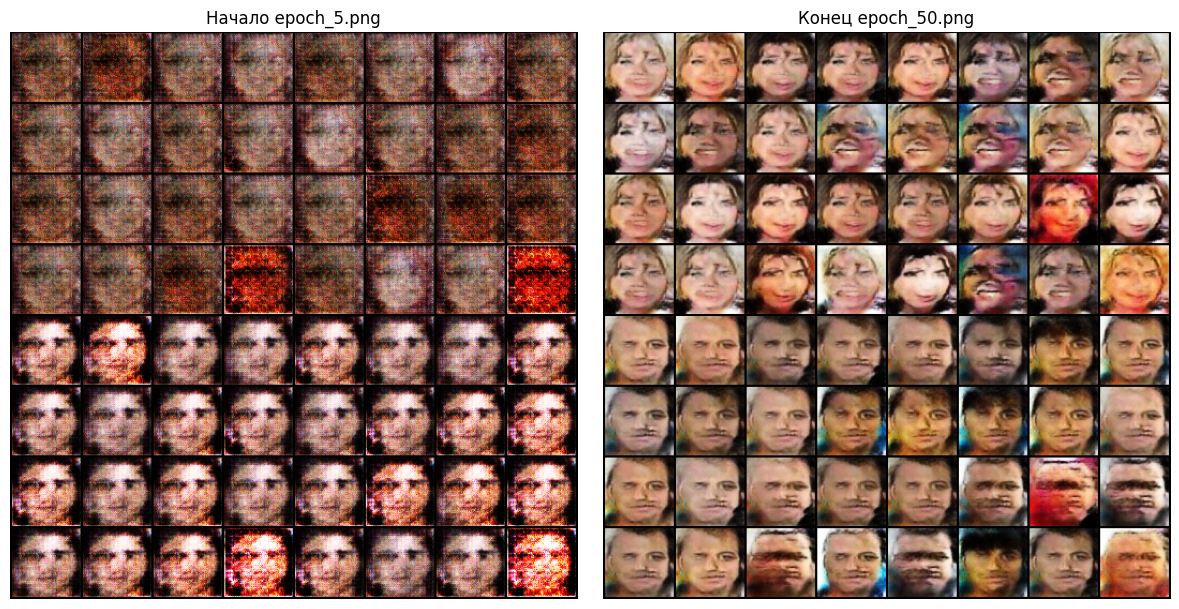

In [24]:
%matplotlib inline

files= [os.path.join("imgs2", f) for f in os.listdir("imgs2") if f.endswith('.png')]
if not files:
    print("пусто")
else:
    files.sort(key=os.path.getmtime)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(plt.imread(files[0]))
    plt.title(f"Начало {os.path.basename(files[0])}")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(plt.imread(files[-1]))
    plt.title(f"Конец {os.path.basename(files[-1])}")
    plt.axis('off')
    plt.tight_layout()
    plt.show();

#### Показать, что из одного вектора шума с разными метками получаются разные изображения

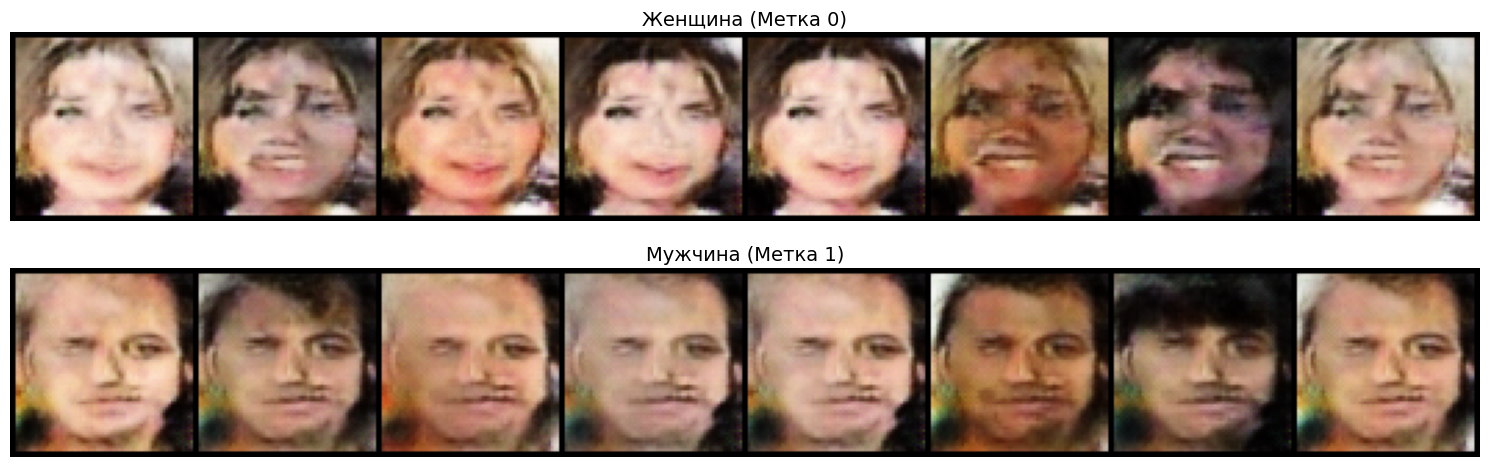

In [15]:
g2.eval()

num_samples = 8
z = torch.randn(num_samples, lat_dim, 1, 1, device=device)

labels_f = torch.zeros(num_samples, dtype=torch.long, device=device)
labels_m = torch.ones(num_samples, dtype=torch.long, device=device)

with torch.no_grad():
    fake_f= g2(z, labels_f).cpu()
    fake_m =g2(z, labels_m).cpu()

fake_f= fake_f * 0.5 + 0.5
fake_m = fake_m * 0.5 + 0.5

grid_f = vutils.make_grid(fake_f, nrow=num_samples, padding=2)
grid_m = vutils.make_grid(fake_m, nrow=num_samples, padding=2)

fig, axes = plt.subplots(2, 1, figsize=(15, 5))

axes[0].imshow(np.transpose(grid_f.numpy(), (1, 2, 0)))
axes[0].set_title("Женщина (Метка 0)", fontsize=14)
axes[0].axis('off')
axes[1].imshow(np.transpose(grid_m.numpy(), (1, 2, 0)))
axes[1].set_title("Мужчина (Метка 1)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig("cgan_comparison.png")
plt.show()

#### Обучите Wasserstein GAN для решения задачи генерации лиц

In [16]:
class WGenerator(nn.Module):
    def __init__(self):
        super(WGenerator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(lat_dim, img_size * 8,4,1,0, bias=False),
            nn.BatchNorm2d(img_size * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(img_size * 8, img_size * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(img_size * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(img_size * 4, img_size * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(img_size * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(img_size * 2, img_size, 4, 2, 1, bias=False),
            nn.BatchNorm2d(img_size),
            nn.ReLU(True),
            nn.ConvTranspose2d(img_size, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

class WCritic(nn.Module):
    def __init__(self):
        super(WCritic, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, img_size, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(img_size, img_size * 2, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(img_size * 2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(img_size * 2, img_size * 4, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(img_size * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(img_size * 4, img_size * 8, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(img_size * 8, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(img_size * 8, 1, 4, 1, 0, bias=False)
        )

    def forward(self, input):
        return self.main(input).view(-1)

In [17]:
def calc_pen(critic, real_samples, fake_samples, device):
    a= torch.rand(real_samples.size(0), 1, 1, 1, device=device)

    inter = (a*real_samples + ((1- a) *fake_samples)).requires_grad_(True)
    d_inter = critic(inter)
    fake = torch.ones(real_samples.size(0), device=device)

    grads= autograd.grad(
        outputs=d_inter,
        inputs=inter,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    grads = grads.view(grads.size(0), -1)
    grad_pen= ((grads.norm(2, dim=1) - 1) ** 2).mean()
    return grad_pen

In [18]:
os.makedirs("imgs_wgan", exist_ok=True)
os.makedirs("weights_wgan", exist_ok=True)

history_wgan = {'c_loss': [], 'g_loss': [],'w_dist': [], 'fid': [], 'is_mean': []
}

fid = FrechetInceptionDistance(feature=2048).to(device)
IS = InceptionScore().to(device)

wG= WGenerator().to(device)
wC= WCritic().to(device)
wG.apply(weights_init)
wC.apply(weights_init)

optimizerC = optim.Adam(wC.parameters(), lr=1e-4, betas=(0.0, 0.9))
optimizerG = optim.Adam(wG.parameters(), lr=1e-4, betas=(0.0, 0.9))

fixed_noise = torch.randn(64, lat_dim, 1, 1, device=device)

for epoch in range(epochs):
    wG.train()
    wC.train()
    
    epoch_c_loss, epoch_g_loss, epoch_w_dist = 0, 0, 0
    
    train_bar = tqdm(dataloader, desc=f"WGAN-GP Epoch {epoch+1}/{epochs}", leave=False)
    
    for i, imgs in enumerate(train_bar):
        real_imgs = imgs[0].to(device) if isinstance(imgs, (list, tuple)) else imgs.to(device)
        b_size = real_imgs.size(0)

        optimizerC.zero_grad()
        real_val = wC(real_imgs)
        
        noise = torch.randn(b_size, lat_dim, 1, 1, device=device)
        fake_imgs = wG(noise)
        fake_val = wC(fake_imgs.detach())
        
        gp= calc_pen(wC, real_imgs.data, fake_imgs.data, device)
        
        loss_C = fake_val.mean() - real_val.mean() + lambda_gp * gp
        loss_C.backward()
        optimizerC.step()
        
        loss_G_val = 0
        if i % n_critic == 0:
            optimizerG.zero_grad()
            gen_imgs = wG(noise)
            loss_G = -wC(gen_imgs).mean()
            loss_G.backward()
            optimizerG.step()
            loss_G_val = loss_G.item()
        epoch_c_loss+= loss_C.item()
        epoch_g_loss+= loss_G_val
        w_dist =(real_val.mean()- fake_val.mean()).item()
        epoch_w_dist+= w_dist
        train_bar.set_postfix(L_C=f"{loss_C.item():.2f}", W_Dist=f"{w_dist:.2f}")
    train_bar.close()

    avg_c= epoch_c_loss/ len(dataloader)
    avg_g= epoch_g_loss/(len(dataloader) // n_critic)
    avg_w= epoch_w_dist /len(dataloader)
    
    history_wgan['c_loss'].append(avg_c)
    history_wgan['g_loss'].append(avg_g)
    history_wgan['w_dist'].append(avg_w)

    is_eval_epoch= (epoch + 1)%5 == 0 or epoch==epochs - 1

    if is_eval_epoch:
        wG.eval()
        fid.reset()
        IS.reset()
        
        print(f"\n[Epoch {epoch+1}]")
        with torch.no_grad():
            fakes_display = wG(fixed_noise)
            grid = make_grid(fakes_display, nrow=8, padding=2, normalize=True)
            save_image(grid, f"imgs_wgan/epoch_{epoch+1}.png")

            s,b= 1000,50
            real_iter= iter(dataloader)
            for _ in range(s // b):
                try: r_imgs = next(real_iter)
                except StopIteration: real_iter = iter(dataloader); r_imgs = next(real_iter)
                
                r_imgs = r_imgs[0].to(device) if isinstance(r_imgs, (list, tuple)) else r_imgs.to(device)
                z = torch.randn(b, lat_dim, 1, 1, device=device)
                f_imgs = wG(z)
                
                fid.update(((r_imgs * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8), real=True)
                fid.update(((f_imgs * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8), real=False)
                IS.update(((f_imgs * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8))

        cur_fid = fid.compute().item()
        cur_is, _ = IS.compute()
        
        history_wgan['fid'].append(cur_fid)
        history_wgan['is_mean'].append(cur_is.item())

        print(f"Epoch {epoch+1} | W-Dist: {avg_w:.3f} | FID: {cur_fid:.2f} | IS: {cur_is.item():.2f}")
        torch.save(wG.state_dict(), f'weights_wgan/netG_epoch_{epoch+1}.pth')

C:\Users\gerta\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)



[Epoch 5]
Epoch 5 | W-Dist: 10.533 | FID: 302.87 | IS: 2.54



[Epoch 10]
Epoch 10 | W-Dist: 9.947 | FID: 185.50 | IS: 2.55



[Epoch 15]
Epoch 15 | W-Dist: 8.914 | FID: 135.20 | IS: 2.36



[Epoch 20]
Epoch 20 | W-Dist: 8.009 | FID: 115.77 | IS: 2.22


...


[Epoch 30]
Epoch 30 | W-Dist: 6.696 | FID: 95.23 | IS: 2.00



[Epoch 35]
Epoch 35 | W-Dist: 6.215 | FID: 87.25 | IS: 1.95



[Epoch 40]
Epoch 40 | W-Dist: 5.819 | FID: 84.35 | IS: 1.94



[Epoch 45]
Epoch 45 | W-Dist: 5.491 | FID: 81.17 | IS: 2.03



[Epoch 50]
Epoch 50 | W-Dist: 5.247 | FID: 79.30 | IS: 1.97


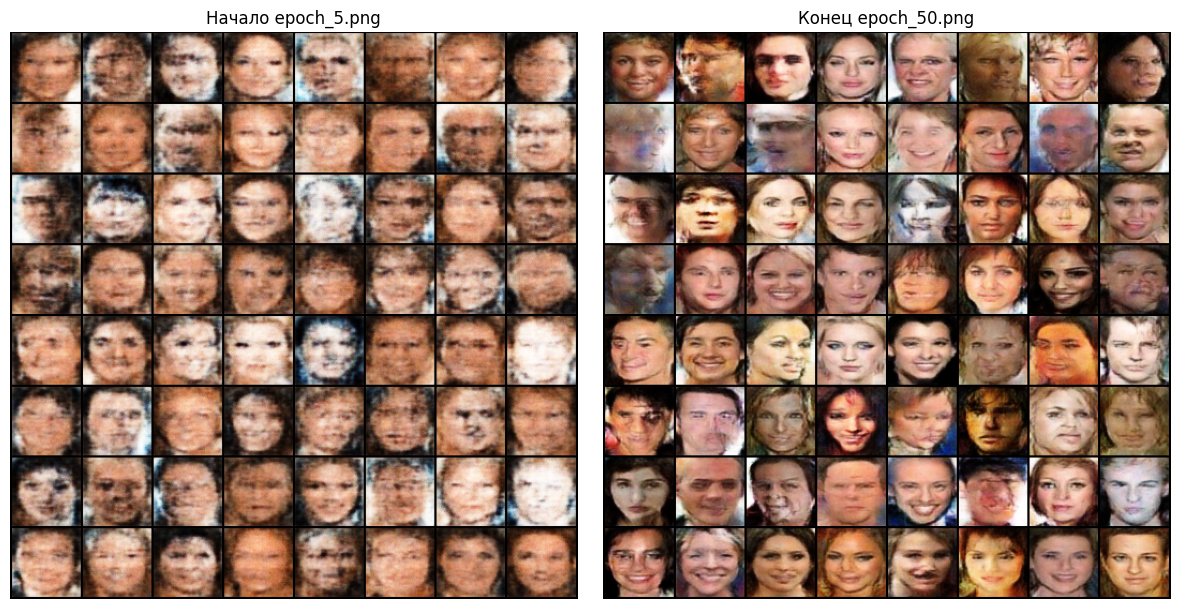

In [23]:
%matplotlib inline

files= [os.path.join("imgs_wgan", f) for f in os.listdir("imgs_wgan") if f.endswith('.png')]
if not files:
    print("пусто")
else:
    files.sort(key=os.path.getmtime)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(plt.imread(files[0]))
    plt.title(f"Начало {os.path.basename(files[0])}")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(plt.imread(files[-1]))
    plt.title(f"Конец {os.path.basename(files[-1])}")
    plt.axis('off')
    plt.tight_layout()
    plt.show();

#### Кривые обучения

##### Безусловная генерация

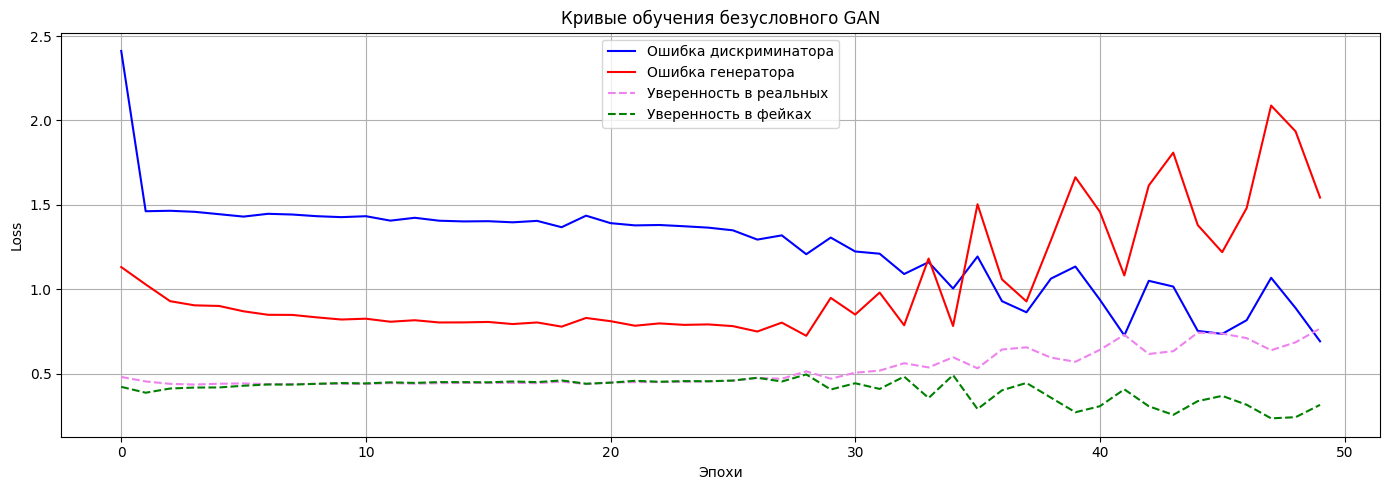

In [28]:
plt.figure(figsize=(14, 5))

plt.plot(history['d_loss'], label='Ошибка дискриминатора', color='blue')
plt.plot(history['g_loss'], label='Ошибка генератора', color='red')
plt.plot(history['D_x'], label='Уверенность в реальных', color='violet', linestyle='--')
plt.plot(history['D_G_z'], label='Уверенность в фейках', color='green', linestyle='--')
plt.title('Кривые обучения безусловного GAN')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

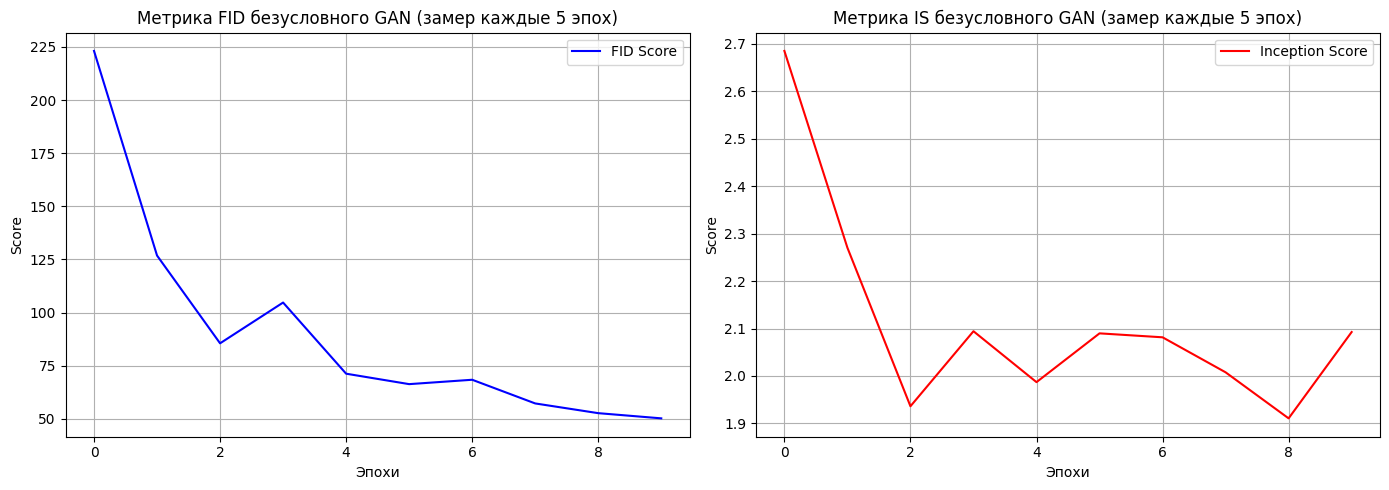

In [29]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history['fid'], label='FID Score', color='blue')
plt.title('Метрика FID безусловного GAN (замер каждые 5 эпох)')
plt.xlabel('Эпохи')
plt.ylabel('Score')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['is_mean'], label='Inception Score', color='red')
plt.title('Метрика IS безусловного GAN (замер каждые 5 эпох)')
plt.xlabel('Эпохи')
plt.ylabel('Score')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

##### Условная генерация

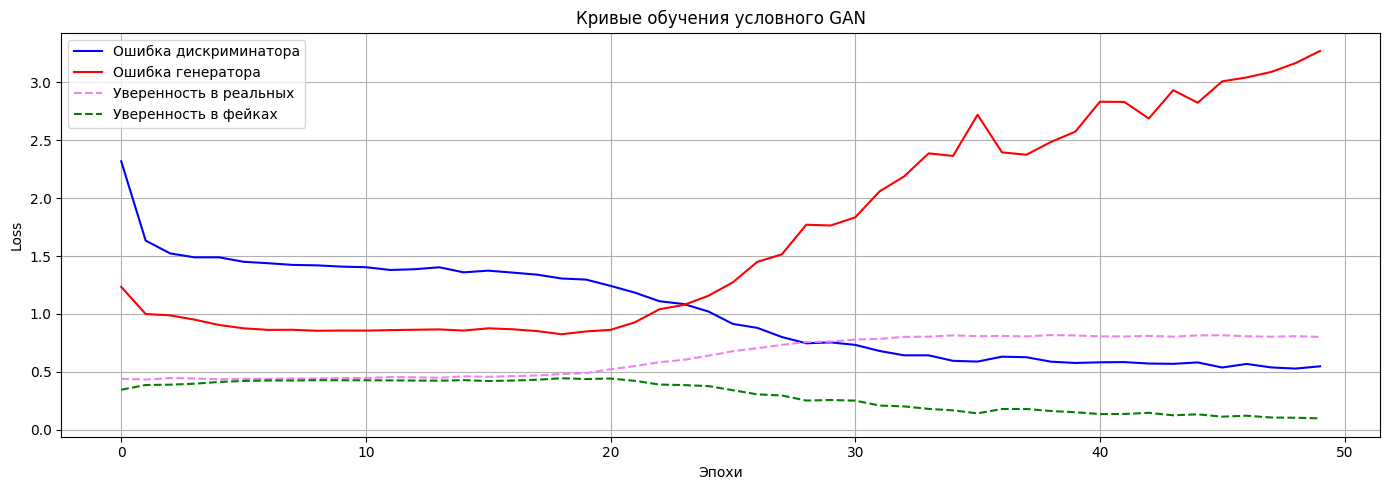

In [30]:
plt.figure(figsize=(14, 5))

plt.plot(history_cond['d_loss'], label='Ошибка дискриминатора', color='blue')
plt.plot(history_cond['g_loss'], label='Ошибка генератора', color='red')
plt.plot(history_cond['D_x'], label='Уверенность в реальных', color='violet', linestyle='--')
plt.plot(history_cond['D_G_z'], label='Уверенность в фейках', color='green', linestyle='--')
plt.title('Кривые обучения условного GAN')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

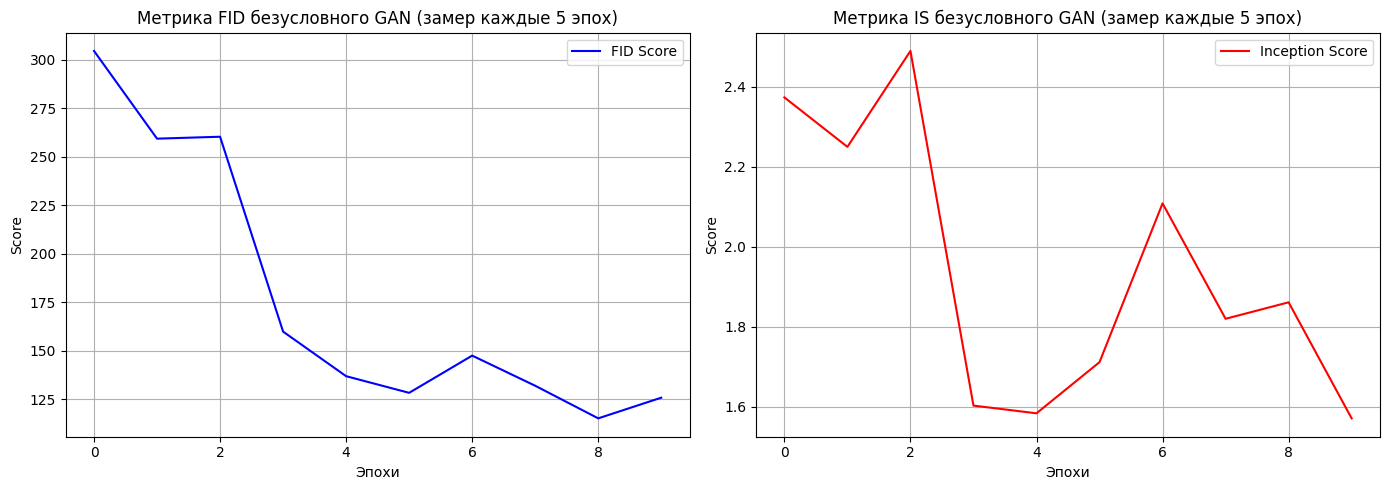

In [31]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_cond['fid'], label='FID Score', color='blue')
plt.title('Метрика FID условного GAN (замер каждые 5 эпох)')
plt.xlabel('Эпохи')
plt.ylabel('Score')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cond['is_mean'], label='Inception Score', color='red')
plt.title('Метрика IS условного GAN (замер каждые 5 эпох)')
plt.xlabel('Эпохи')
plt.ylabel('Score')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

##### Wasserstein GAN

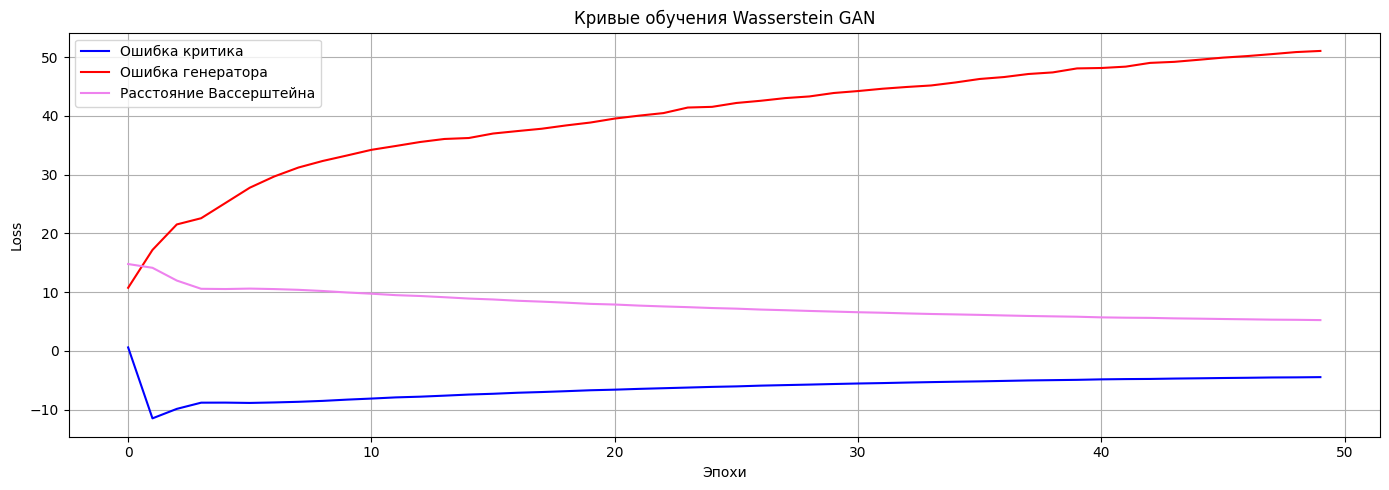

In [33]:
plt.figure(figsize=(14, 5))

plt.plot(history_wgan['c_loss'], label='Ошибка критика', color='blue')
plt.plot(history_wgan['g_loss'], label='Ошибка генератора', color='red')
plt.plot(history_wgan['w_dist'], label='Расстояние Вассерштейна', color='violet')
plt.title('Кривые обучения Wasserstein GAN')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

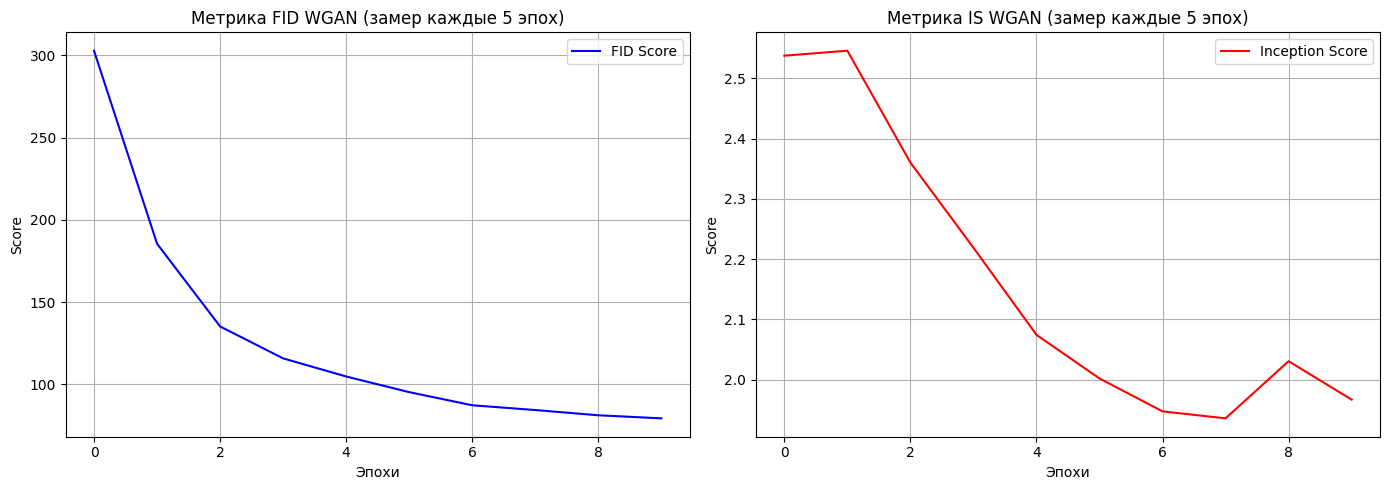

In [34]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_wgan['fid'], label='FID Score', color='blue')
plt.title('Метрика FID WGAN (замер каждые 5 эпох)')
plt.xlabel('Эпохи')
plt.ylabel('Score')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_wgan['is_mean'], label='Inception Score', color='red')
plt.title('Метрика IS WGAN (замер каждые 5 эпох)')
plt.xlabel('Эпохи')
plt.ylabel('Score')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()